In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
df = pd.read_csv(r"C:/College/CSE-AI/4th Sem/DL/DL_Lab/Tweets.csv")

print("Dataset Loaded ")
print(df.head())

Dataset Loaded 
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [3]:

df = df[['text', 'sentiment']]

df = df.dropna(subset=['text', 'sentiment'])


df['text'] = df['text'].astype(str)


df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()


df['sentiment'] = df['sentiment'].map({
    'negative': 0,
    'neutral': 1,
    'positive': 2
})


df = df[df['sentiment'].isin([0,1,2])]


df['sentiment'] = df['sentiment'].astype('int32')


print("Unique labels:", df['sentiment'].unique())
print("Shape:", df.shape)

Unique labels: [1 0 2]
Shape: (27480, 2)


In [4]:
x = df['text']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


y_train = np.array(y_train).astype('int32')
y_test = np.array(y_test).astype('int32')

print("Train size:", len(x_train))
print("Test size:", len(x_test))

Train size: 21984
Test size: 5496


In [5]:
vocab_size = 10000
max_len = 50

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(x_train)

x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Shape after padding:", x_train.shape)

Shape after padding: (21984, 50)


In [6]:
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_len))
    
    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))
    
    model.add(Dense(3, activation='softmax'))
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [7]:
results = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type}...")
    
    model = build_model(model_type)
    
    start = time.time()
    
    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )
    
    training_time = time.time() - start
    
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    results[model_type] = {
        "accuracy": test_acc,
        "loss": test_loss,
        "time": training_time
    }


Training RNN...
Epoch 1/3


c:\Users\praga\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4591 - loss: 1.0286 - val_accuracy: 0.5793 - val_loss: 0.9065
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7196 - loss: 0.7012 - val_accuracy: 0.6222 - val_loss: 0.8393
Epoch 3/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8765 - loss: 0.3588 - val_accuracy: 0.6141 - val_loss: 0.9652

Training LSTM...
Epoch 1/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4887 - loss: 1.0027 - val_accuracy: 0.6015 - val_loss: 0.8736
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7092 - loss: 0.6888 - val_accuracy: 0.6918 - val_loss: 0.7271
Epoch 3/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7941 - loss: 0.5256 - val_accuracy: 0.6868 - val_loss: 0.7413

Training GRU...
Epoch 1/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5283 - loss: 0.9450 - val_accuracy: 0.6495 - val_loss: 0.7893
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7379 - loss: 0

In [8]:
print("\n Final Results:\n")

for model in results:
    print(f"{model}:")
    print(f" Accuracy: {results[model]['accuracy']:.4f}")
    print(f" Loss: {results[model]['loss']:.4f}")
    print(f" Time: {results[model]['time']:.2f}s\n")


 Final Results:

RNN:
 Accuracy: 0.6248
 Loss: 0.9284
 Time: 5.60s

LSTM:
 Accuracy: 0.6901
 Loss: 0.7299
 Time: 13.72s

GRU:
 Accuracy: 0.6856
 Loss: 0.7845
 Time: 14.55s



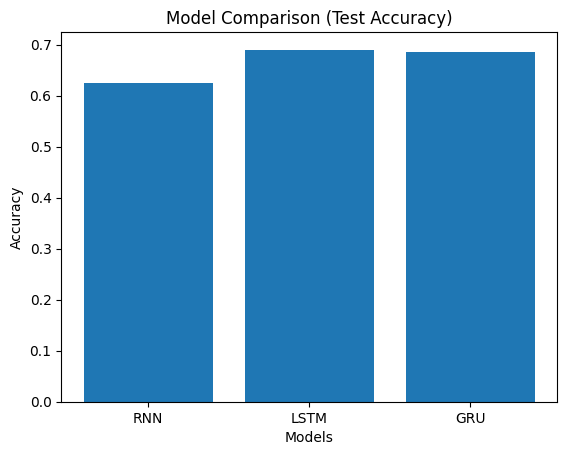

In [9]:
models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]

plt.bar(models, accuracies)
plt.title("Model Comparison (Test Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

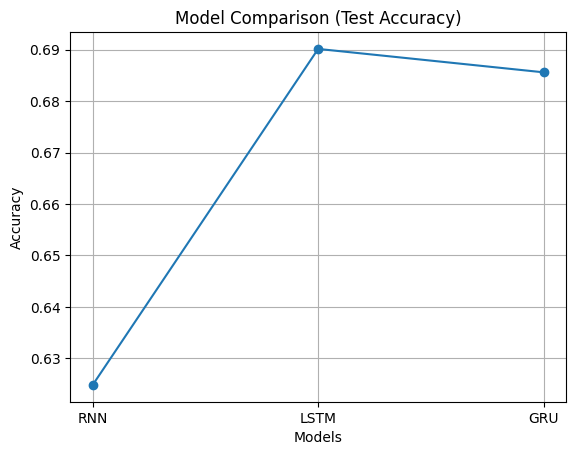

In [10]:
models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]

plt.plot(models, accuracies, marker='o')
plt.title("Model Comparison (Test Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [11]:
histories = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type}...")
    
    model = build_model(model_type)
    
    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )
    
    histories[model_type] = history


Training RNN...
Epoch 1/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4493 - loss: 1.0471 - val_accuracy: 0.5244 - val_loss: 0.9553
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7050 - loss: 0.7208 - val_accuracy: 0.6393 - val_loss: 0.8107
Epoch 3/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8683 - loss: 0.3757 - val_accuracy: 0.6327 - val_loss: 0.9192

Training LSTM...
Epoch 1/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5423 - loss: 0.9251 - val_accuracy: 0.6632 - val_loss: 0.7745
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7370 - loss: 0.6353 - val_accuracy: 0.6834 - val_loss: 0.7454
Epoch 3/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7562 - loss: 0.6028 - val_accuracy: 0.6807 - val_loss: 0.7759

Training GRU...
Epoch 1/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5439 - loss: 0.9212 - val_accuracy: 0.6584 - val_loss: 0.7652
Epoch 2/3
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step 

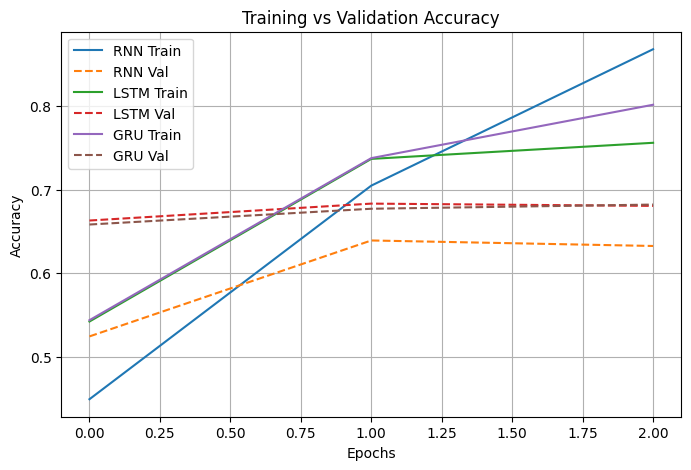

In [12]:
plt.figure(figsize=(8,5))

for model in histories:
    plt.plot(histories[model].history['accuracy'], label=f"{model} Train")
    plt.plot(histories[model].history['val_accuracy'], linestyle='dashed', label=f"{model} Val")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

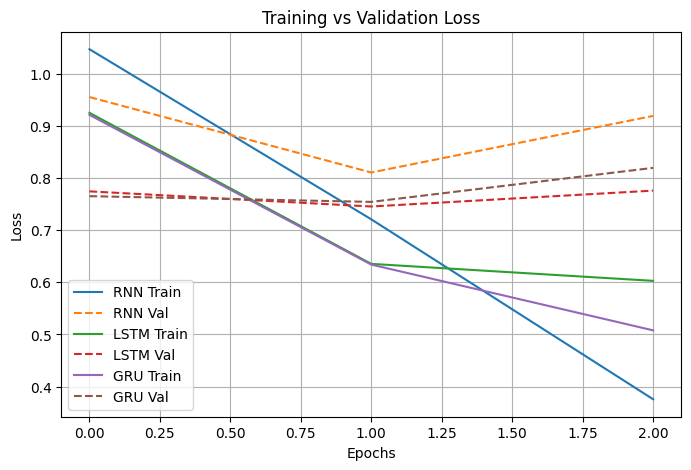

In [13]:
plt.figure(figsize=(8,5))

for model in histories:
    plt.plot(histories[model].history['loss'], label=f"{model} Train")
    plt.plot(histories[model].history['val_loss'], linestyle='dashed', label=f"{model} Val")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

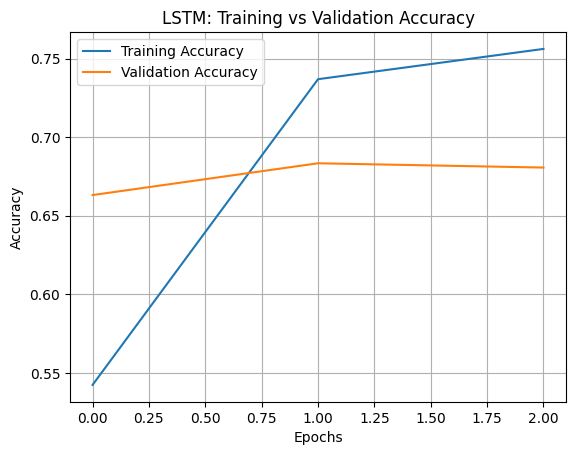

In [14]:
history = histories["LSTM"]

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM: Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()